In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd
import nltk
import numpy as np
import re
import json

In [45]:
df = pd.read_excel("/content/drive/MyDrive/2024춘계_KOSMI_튜토리얼_01/radiology_report_data/WholeSpine700test.xlsx")

In [46]:
df.head()

,Reports,GT_label
0,Clinical information: Medulloblastoma \n \nWh...,no
1,EXAM: Whole spine MRI with contrast enhancemen...,mets
2,EXAM : Whole spine enhanced MRI with tumor pro...,progression
3,\n\nEXAM: Whole spine MRI with enhancement. \n...,no
4,\n\nEXAM: Whole spine contrast enhanced MRI \...,stable


## 결측값 유무 확인

In [47]:
df.isnull().sum()

Reports     0
GT_label    0
dtype: int64

## 각 라벨별 빈도를 계산.

In [48]:
df.groupby('GT_label').count()

,Reports
GT_label,
No,1
improved,110
mets,120
no,112
no,1
progression,121
romets,111
stable,124


### no, No, no(오른쪽 공백)으로 나눠짐~ -> 통일해줘야 한다~

In [49]:
len(df['GT_label'][df['GT_label']=='no'])

112

In [50]:
len(df['GT_label'][df['GT_label']=='no '])

1

In [51]:
len(df['GT_label'][df['GT_label']=='No'])

1

## no, No, no(오른쪽 공백)' 을 정규표현식을 이용해 'no'로 통일하여 다시 빈도수를 계산

In [52]:
df['GT_label'] = df['GT_label'].apply(lambda x : re.sub(r'[N|n]o\s*','no',x))
df.groupby('GT_label').count()

,Reports
GT_label,
improved,110
mets,120
no,114
progression,121
romets,111
stable,124


In [53]:
aggregated_df=df.groupby('GT_label').count()

## 라벨별 빈도수를 시각화해보았다.
### 거의 균등한 분포를 보인다!

<Axes: xlabel='GT_label'>

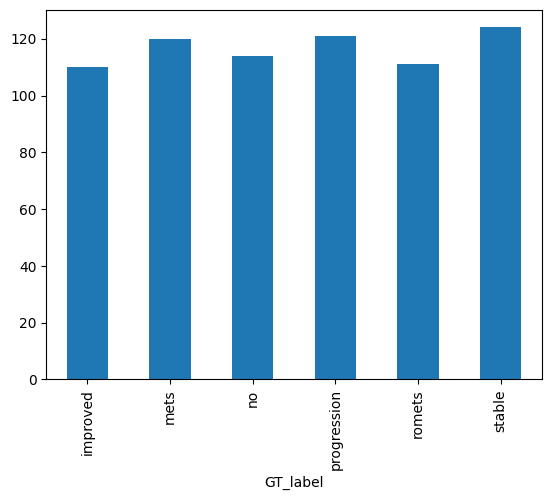

In [54]:
aggregated_df.plot(kind='bar', legend=False)

### 분포를 비율로 변환해 보았을 때에도 각 라벨별로 비율 차이가 심하게 나지 않는다는 걸 알 수 있었다.

In [55]:
aggregated_df['Ratio(%)'] = round((aggregated_df['Reports'] / aggregated_df['Reports'].sum())*100,2)
aggregated_df

,Reports,Ratio(%)
GT_label,,
improved,110,15.71
mets,120,17.14
no,114,16.29
progression,121,17.29
romets,111,15.86
stable,124,17.71


In [56]:
ratio_diff= aggregated_df['Ratio(%)'].max() - aggregated_df['Ratio(%)'].min()
print(f'최대 비율과 최소 비율의 차이는 {ratio_diff} % 만큼 차이난다.')

최대 비율과 최소 비율의 차이는 2.0 % 만큼 차이난다.


In [58]:
ratio_diff= aggregated_df['Ratio(%)'].max() / aggregated_df['Ratio(%)'].min()
print(f'최대 비율과 최소 비율의 배수 차이는 {ratio_diff} 배 만큼 차이난다.') #약 1.12배 차이난다

최대 비율과 최소 비율의 배수 차이는 1.127307447485678 배 만큼 차이난다.


## 개정된 파일 저장

In [59]:
df.to_csv("/content/drive/MyDrive/2024춘계_KOSMI_튜토리얼_01/radiology_report_data/WholeSpineVersion2.csv", index=False)

In [60]:
pd.read_csv("/content/drive/MyDrive/2024춘계_KOSMI_튜토리얼_01/radiology_report_data/WholeSpineVersion2.csv")

,Reports,GT_label
0,Clinical information: Medulloblastoma \n \nWh...,no
1,EXAM: Whole spine MRI with contrast enhancemen...,mets
2,EXAM : Whole spine enhanced MRI with tumor pro...,progression
3,\n\nEXAM: Whole spine MRI with enhancement. \n...,no
4,\n\nEXAM: Whole spine contrast enhanced MRI \...,stable
...,...,...
695,EXAM : Whole spine MRI with contrast enhanceme...,no
696,Exam : Whole spine MR with contrast enhancemen...,no
697,\nExam: Whole-spine MRI with contrast enhancem...,romets
698,Exam: Whole-spine MRI with contrast enhancemen...,progression
